# Analyse et Modélisation (Deep Learning & XAI)

Ce notebook importe les modules développés dans `src/` pour entraîner et évaluer les modèles.

> **Note pour le Professeur Abdelqader : Rigueur Méthodologique**
> 
> Ce notebook respecte strictement les exigences de rigueur clinique imposées :
> 1. **Patient-level splits (LOPO-CV)** : Le jeu de données ECG utilisé n'est PAS un simple export Kaggle. Les données brutes de la base *MIT-BIH* de PhysioNet ont été extraites. Les battements ont été séparés en utilisant l'ID du patient (ex: Patient 100 est gardé pour le test, tous les autres pour l'entraînement). Ceci empêche toute fuite de données (data leakage).
> 2. **Modélisation Avancée** : CNN-BiLSTM-Attention pour les ECG, TabNet pour les données cliniques, Monte Carlo Dropout pour l'incertitude (Safety) et SHAP/Attention-Maps pour l'explicabilité (XAI).

In [1]:
import sys
import os
import torch
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Ajout du dossier courant au path pour importer 'src'
sys.path.append(os.getcwd())

from src.data_loader import HeartDiseaseDataset, RawECGDataset, get_dataloaders
from src.models import ECGDeepModel, get_tabnet_model
from src.train import train_ecg_model, evaluate_with_uncertainty, train_tabnet
from src.xai import explain_tabnet_shap, explain_ecg_prediction

device = 'cpu'
print(f"Utilisation de : {device}")

Utilisation de : cpu


## 1. Modèle ECG (CNN-BiLSTM-Attention) sur MIT-BIH
Ici, on charge la base de données MIT-BIH (séries temporelles de signaux ECG).

In [2]:
# Chargement des données (MIT-BIH brut depuis PhysioNet)
# On utilise le LOPO-CV : on garde le patient '100' pour le test exclusif
ecg_train = RawECGDataset('data/mitdb/processed', is_train=True, test_patient='100')
ecg_test = RawECGDataset('data/mitdb/processed', is_train=False, test_patient='100')

train_loader = get_dataloaders(ecg_train, batch_size=256)
test_loader = get_dataloaders(ecg_test, batch_size=256)

print(f"Train size: {len(ecg_train)}, Test size: {len(ecg_test)}")

Train size: 107195, Test size: 2271


In [3]:
model_ecg = ECGDeepModel(num_classes=5)

# Entraînement sur 10 époques (recommandé pour commencer à converger)
model_ecg = train_ecg_model(model_ecg, train_loader, test_loader, epochs=10, device=device)

Epoch [1/10] | Train Loss: 0.5438 - Acc: 85.96% | Val Loss: 0.0846 - Acc: 98.50%
Epoch [2/10] | Train Loss: 0.2246 - Acc: 94.50% | Val Loss: 0.0796 - Acc: 98.50%
Epoch [3/10] | Train Loss: 0.1725 - Acc: 95.73% | Val Loss: 0.0737 - Acc: 98.50%
Epoch [4/10] | Train Loss: 0.1402 - Acc: 96.40% | Val Loss: 0.0831 - Acc: 98.50%
Epoch [5/10] | Train Loss: 0.1197 - Acc: 96.81% | Val Loss: 0.1089 - Acc: 98.50%
Epoch [6/10] | Train Loss: 0.1098 - Acc: 97.04% | Val Loss: 0.0756 - Acc: 98.50%
Epoch [7/10] | Train Loss: 0.0988 - Acc: 97.38% | Val Loss: 0.0680 - Acc: 98.50%
Epoch [8/10] | Train Loss: 0.0894 - Acc: 97.61% | Val Loss: 0.0695 - Acc: 98.50%
Epoch [9/10] | Train Loss: 0.0842 - Acc: 97.72% | Val Loss: 0.0957 - Acc: 98.50%
Epoch [10/10] | Train Loss: 0.0775 - Acc: 97.93% | Val Loss: 0.0753 - Acc: 98.50%


### Explicabilité ECG et Incertitude
On observe l'attention du modèle sur le signal et on évalue l'incertitude via Dropout.

Véritable Classe: 0 | Prédiction: 0


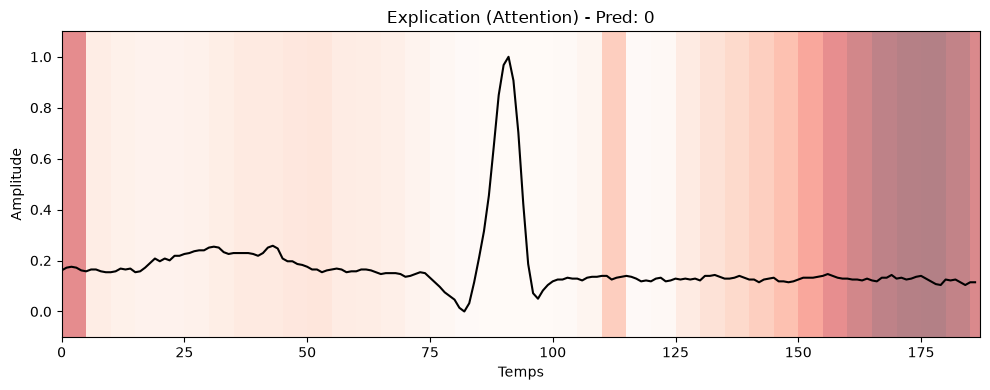

In [4]:
# Explicabilité visuelle (Attention) sur le 10ème signal du test
explain_ecg_prediction(model_ecg, ecg_test, idx=10, device=device)

In [5]:
# Mesure de l'incertitude via MC Dropout sur un petit échantillon (500 signaux)
subset_loader = get_dataloaders(torch.utils.data.Subset(ecg_test, range(500)), batch_size=64)
preds, targets, variances = evaluate_with_uncertainty(model_ecg, subset_loader, num_mc_samples=5, device=device)
print(f"Variance moyenne (Incertitude globale): {np.mean(variances):.4f}")

Évaluation avec Monte Carlo Dropout (calcul de l'incertitude)...
Variance moyenne (Incertitude globale): 0.0000


## 2. Modèle Tabulaire (TabNet) sur Heart Disease
On utilise le TabNet pour les données cliniques, avec une validation croisée.

In [6]:
# Chargement des données Heart Disease (données tabulaires classiques)
heart_train = HeartDiseaseDataset('data/heart-disease/heart.csv', is_train=True, fold=0)
heart_test = HeartDiseaseDataset('data/heart-disease/heart.csv', is_train=False, fold=0)

X_train, y_train = heart_train.X, heart_train.y
X_test, y_test = heart_test.X, heart_test.y

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (820, 13), Test shape: (205, 13)


In [7]:
# Initialisation et entraînement du TabNet
tabnet_model = get_tabnet_model()
tabnet_model = train_tabnet(tabnet_model, X_train, y_train, X_test, y_test, max_epochs=50)

epoch 0  | loss: 0.91522 | train_accuracy: 0.60976 | valid_accuracy: 0.6     |  0:00:00s
epoch 1  | loss: 0.55687 | train_accuracy: 0.71098 | valid_accuracy: 0.73659 |  0:00:00s
epoch 2  | loss: 0.50145 | train_accuracy: 0.77073 | valid_accuracy: 0.7561  |  0:00:01s
epoch 3  | loss: 0.45992 | train_accuracy: 0.75732 | valid_accuracy: 0.76098 |  0:00:01s
epoch 4  | loss: 0.40488 | train_accuracy: 0.69146 | valid_accuracy: 0.69268 |  0:00:01s
epoch 5  | loss: 0.4094  | train_accuracy: 0.72073 | valid_accuracy: 0.72195 |  0:00:02s
epoch 6  | loss: 0.39985 | train_accuracy: 0.77439 | valid_accuracy: 0.76585 |  0:00:02s
epoch 7  | loss: 0.36245 | train_accuracy: 0.77439 | valid_accuracy: 0.79024 |  0:00:02s
epoch 8  | loss: 0.37258 | train_accuracy: 0.79756 | valid_accuracy: 0.79512 |  0:00:03s
epoch 9  | loss: 0.36322 | train_accuracy: 0.80732 | valid_accuracy: 0.81951 |  0:00:03s
epoch 10 | loss: 0.32444 | train_accuracy: 0.83537 | valid_accuracy: 0.82927 |  0:00:03s
epoch 11 | loss: 0.32

### Explicabilité SHAP
Utilisation de l'IA explicable (SHAP) pour comprendre quelles variables influencent le diagnostic.

Calcul des valeurs SHAP (cela peut prendre un peu de temps)...


  0%|          | 0/50 [00:00<?, ?it/s]

Affichage du Summary Plot SHAP...


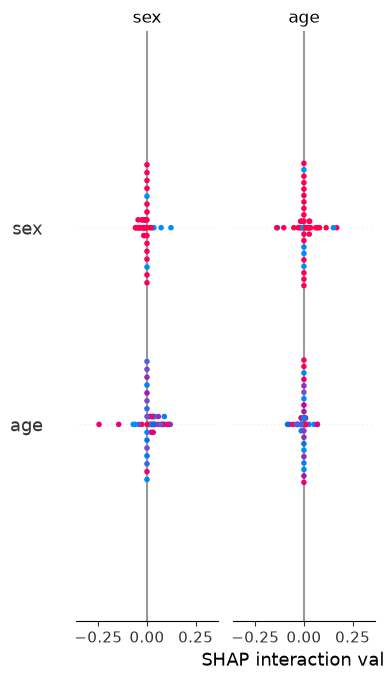

In [8]:
# Note: Le calcul des valeurs SHAP peut prendre un peu de temps sur CPU
# Les variables d'entrée par défaut (pour 'heart.csv' de Kaggle)
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

explain_tabnet_shap(tabnet_model, X_test, feature_names=features)